In [1]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH)

db_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

salary_postings = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            job_title_short,
            job_country,
            salary_year_avg
        FROM data_jobs.job_postings_fact
        WHERE salary_year_avg IS NOT NULL
        """
    ),
    con=engine,
)

skills = pd.read_sql_query(
    sql=text(
        """
        SELECT
            skill_id,
            skills AS skill_name,
            type AS skill_type
        FROM data_jobs.skills_dim
        """
    ),
    con=engine,
)

job_skills = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            skill_id
        FROM data_jobs.skills_job_dim
        """
    ),
    con=engine,
)

print("Loaded DataFrames:")
print(f"- salary_postings: {salary_postings.shape[0]:,} rows × {salary_postings.shape[1]} columns")
print(f"- skills: {skills.shape[0]:,} rows × {skills.shape[1]} columns")
print(f"- job_skills: {job_skills.shape[0]:,} rows × {job_skills.shape[1]} columns")

Loaded DataFrames:
- salary_postings: 20,335 rows × 4 columns
- skills: 254 rows × 3 columns
- job_skills: 2,274,756 rows × 2 columns


In [2]:
salary_postings_with_skills = (
    salary_postings
    .merge(
        job_skills,
        on="job_id",
        how="inner",
        validate="one_to_many",
    )
    .merge(
        skills,
        on="skill_id",
        how="inner",
        validate="many_to_one",
    )
)

salary_skill_join_summary = pd.DataFrame(
    {
        "metric": [
            "postings_with_disclosed_annual_salary",
            "disclosed_salary_postings_with_at_least_one_skill",
            "disclosed_salary_postings_without_any_skill",
            "share_of_disclosed_salary_postings_with_skills_pct",
            "job_skill_rows_after_join",
            "unique_jobs_after_join",
            "unique_skills_after_join",
            "duplicated_job_skill_pairs_after_join",
            "rows_lost_from_salary_postings",
        ],
        "value": [
            len(salary_postings),
            salary_postings_with_skills["job_id"].nunique(),
            len(salary_postings)
            - salary_postings_with_skills["job_id"].nunique(),
            round(
                salary_postings_with_skills["job_id"].nunique()
                / len(salary_postings)
                * 100,
                2,
            ),
            len(salary_postings_with_skills),
            salary_postings_with_skills["job_id"].nunique(),
            salary_postings_with_skills["skill_id"].nunique(),
            salary_postings_with_skills.duplicated(
                subset=["job_id", "skill_id"]
            ).sum(),
            len(salary_postings)
            - salary_postings_with_skills["job_id"].nunique(),
        ],
    }
)

display(salary_skill_join_summary)

display(salary_postings_with_skills.head())

,metric,value
0,postings_with_disclosed_annual_salary,"20,335.00"
1,disclosed_salary_postings_with_at_least_one_skill,"18,531.00"
2,disclosed_salary_postings_without_any_skill,"1,804.00"
3,share_of_disclosed_salary_postings_with_skills...,91.13
4,job_skill_rows_after_join,"102,742.00"
5,unique_jobs_after_join,"18,531.00"
6,unique_skills_after_join,216.00
7,duplicated_job_skill_pairs_after_join,0.00
8,rows_lost_from_salary_postings,"1,804.00"


,job_id,job_title_short,job_country,salary_year_avg,skill_id,skill_name,skill_type
0,42876,Data Scientist,Sudan,"125,000.00",0,sql,programming
1,42876,Data Scientist,Sudan,"125,000.00",1,python,programming
2,42876,Data Scientist,Sudan,"125,000.00",65,neo4j,databases
3,42876,Data Scientist,Sudan,"125,000.00",78,azure,cloud
4,42876,Data Scientist,Sudan,"125,000.00",92,pytorch,libraries


In [3]:
annual_salary_reference = pd.DataFrame(
    {
        "metric": [
            "disclosed_salary_postings_total",
            "disclosed_salary_postings_with_skills",
            "reference_median_annual_salary",
            "reference_mean_annual_salary",
            "reference_p25_annual_salary",
            "reference_p75_annual_salary",
            "reference_p95_annual_salary",
            "reference_p99_annual_salary",
        ],
        "value": [
            len(salary_postings),
            salary_postings_with_skills["job_id"].nunique(),
            salary_postings["salary_year_avg"].median(),
            salary_postings["salary_year_avg"].mean(),
            salary_postings["salary_year_avg"].quantile(0.25),
            salary_postings["salary_year_avg"].quantile(0.75),
            salary_postings["salary_year_avg"].quantile(0.95),
            salary_postings["salary_year_avg"].quantile(0.99),
        ],
    }
)

display(annual_salary_reference)

,metric,value
0,disclosed_salary_postings_total,"20,335.00"
1,disclosed_salary_postings_with_skills,"18,531.00"
2,reference_median_annual_salary,"113,250.00"
3,reference_mean_annual_salary,"120,587.93"
4,reference_p25_annual_salary,"85,975.00"
5,reference_p75_annual_salary,"149,589.00"
6,reference_p95_annual_salary,"209,000.00"
7,reference_p99_annual_salary,"255,000.00"


In [4]:
skill_salary_sample_profile = (
    salary_postings_with_skills
    .groupby(
        [
            "skill_id",
            "skill_name",
            "skill_type",
        ],
        as_index=False,
    )
    .agg(
        disclosed_salary_postings=("job_id", "nunique"),
        median_annual_salary=("salary_year_avg", "median"),
        mean_annual_salary=("salary_year_avg", "mean"),
        p25_annual_salary=(
            "salary_year_avg",
            lambda values: values.quantile(0.25),
        ),
        p75_annual_salary=(
            "salary_year_avg",
            lambda values: values.quantile(0.75),
        ),
    )
)

skill_salary_sample_profile = skill_salary_sample_profile.sort_values(
    by="disclosed_salary_postings",
    ascending=False,
).reset_index(drop=True)

salary_sample_threshold_summary = pd.DataFrame(
    {
        "minimum_disclosed_salary_postings": [
            10,
            25,
            50,
            100,
            250,
            500,
            1_000,
            2_500,
        ],
    }
)

salary_sample_threshold_summary["skills_meeting_threshold"] = (
    salary_sample_threshold_summary[
        "minimum_disclosed_salary_postings"
    ].apply(
        lambda threshold: (
            skill_salary_sample_profile[
                "disclosed_salary_postings"
            ] >= threshold
        ).sum()
    )
)

salary_sample_threshold_summary["share_of_all_skills_pct"] = (
    salary_sample_threshold_summary["skills_meeting_threshold"]
    / len(skill_salary_sample_profile)
    * 100
).round(2)

print("Top 30 skills by number of postings with disclosed annual salary:")
display(skill_salary_sample_profile.head(30))

print("\nDisclosed-salary sample threshold profile:")
display(salary_sample_threshold_summary)

Top 30 skills by number of postings with disclosed annual salary:


,skill_id,skill_name,skill_type,disclosed_salary_postings,median_annual_salary,mean_annual_salary,p25_annual_salary,p75_annual_salary
0,0,sql,programming,11006,"120,000.00","123,543.49","95,000.00","150,000.00"
1,1,python,programming,10900,"125,000.00","130,296.77","100,000.00","157,737.62"
2,177,excel,analyst_tools,4574,"90,000.00","95,203.44","75,000.00","112,500.00"
3,2,r,programming,4506,"123,800.00","126,692.50","95,076.25","153,500.00"
4,178,tableau,analyst_tools,4267,"108,415.50","111,340.91","85,000.00","135,000.00"
5,75,aws,cloud,4106,"125,000.00","131,982.02","101,014.00","159,986.00"
6,78,azure,cloud,3187,"125,000.00","127,859.55","100,000.00","154,000.00"
7,94,spark,libraries,3171,"135,587.50","139,194.68","108,415.50","162,500.00"
8,182,power bi,analyst_tools,2769,"100,000.00","104,340.89","80,000.00","129,550.00"
9,8,java,programming,2294,"130,098.50","134,498.05","100,125.00","162,500.00"



Disclosed-salary sample threshold profile:


,minimum_disclosed_salary_postings,skills_meeting_threshold,share_of_all_skills_pct
0,10,170,78.70
1,25,140,64.81
2,50,125,57.87
3,100,102,47.22
4,250,68,31.48
5,500,48,22.22
6,1000,26,12.04
7,2500,9,4.17


In [5]:
MIN_DISCLOSED_SALARY_POSTINGS = 100

reference_median_annual_salary = (
    salary_postings["salary_year_avg"].median()
)

skill_salary_premium = (
    skill_salary_sample_profile
    .loc[
        skill_salary_sample_profile[
            "disclosed_salary_postings"
        ] >= MIN_DISCLOSED_SALARY_POSTINGS
    ]
    .copy()
)

skill_salary_premium["reference_median_annual_salary"] = (
    reference_median_annual_salary
)

skill_salary_premium["salary_premium_abs"] = (
    skill_salary_premium["median_annual_salary"]
    - skill_salary_premium["reference_median_annual_salary"]
)

skill_salary_premium["salary_premium_pct"] = (
    skill_salary_premium["salary_premium_abs"]
    / skill_salary_premium["reference_median_annual_salary"]
    * 100
).round(2)

skill_salary_premium = skill_salary_premium.sort_values(
    by=[
        "salary_premium_pct",
        "disclosed_salary_postings",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

skill_salary_premium_threshold_summary = pd.DataFrame(
    {
        "metric": [
            "minimum_disclosed_salary_postings",
            "reference_median_annual_salary",
            "skills_in_full_salary_profile",
            "skills_meeting_salary_sample_threshold",
            "share_of_skills_meeting_threshold_pct",
        ],
        "value": [
            MIN_DISCLOSED_SALARY_POSTINGS,
            reference_median_annual_salary,
            len(skill_salary_sample_profile),
            len(skill_salary_premium),
            round(
                len(skill_salary_premium)
                / len(skill_salary_sample_profile)
                * 100,
                2,
            ),
        ],
    }
)

display(skill_salary_premium_threshold_summary)

print("\nTop 30 skills by annual salary premium:")
display(
    skill_salary_premium[
        [
            "skill_name",
            "skill_type",
            "disclosed_salary_postings",
            "median_annual_salary",
            "reference_median_annual_salary",
            "salary_premium_abs",
            "salary_premium_pct",
        ]
    ].head(30)
)

,metric,value
0,minimum_disclosed_salary_postings,100.00
1,reference_median_annual_salary,"113,250.00"
2,skills_in_full_salary_profile,216.00
3,skills_meeting_salary_sample_threshold,102.00
4,share_of_skills_meeting_threshold_pct,47.22



Top 30 skills by annual salary premium:


,skill_name,skill_type,disclosed_salary_postings,median_annual_salary,reference_median_annual_salary,salary_premium_abs,salary_premium_pct
0,golang,programming,116,"175,000.00","113,250.00","61,750.00",54.53
1,redis,databases,153,"170,000.00","113,250.00","56,750.00",50.11
2,slack,sync,152,"170,000.00","113,250.00","56,750.00",50.11
3,node.js,webframeworks,125,"170,000.00","113,250.00","56,750.00",50.11
4,ruby,programming,125,"170,000.00","113,250.00","56,750.00",50.11
5,ruby,webframeworks,125,"170,000.00","113,250.00","56,750.00",50.11
6,zoom,sync,118,"170,000.00","113,250.00","56,750.00",50.11
7,mongo,programming,123,"165,000.00","113,250.00","51,750.00",45.70
8,react,libraries,229,"150,000.00","113,250.00","36,750.00",32.45
9,matplotlib,libraries,317,"146,500.00","113,250.00","33,250.00",29.36


In [6]:
top_skills_by_disclosed_salary_sample = (
    skill_salary_premium
    .sort_values(
        by="disclosed_salary_postings",
        ascending=False,
    )
    .head(30)
    .reset_index(drop=True)
)

lowest_skill_salary_premium = (
    skill_salary_premium
    .sort_values(
        by=[
            "salary_premium_pct",
            "disclosed_salary_postings",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .head(30)
    .reset_index(drop=True)
)

print("Top 30 skills by disclosed annual-salary sample size:")
display(
    top_skills_by_disclosed_salary_sample[
        [
            "skill_name",
            "skill_type",
            "disclosed_salary_postings",
            "median_annual_salary",
            "salary_premium_abs",
            "salary_premium_pct",
        ]
    ]
)

print("\nBottom 30 skills by annual salary premium:")
display(
    lowest_skill_salary_premium[
        [
            "skill_name",
            "skill_type",
            "disclosed_salary_postings",
            "median_annual_salary",
            "salary_premium_abs",
            "salary_premium_pct",
        ]
    ]
)

Top 30 skills by disclosed annual-salary sample size:


,skill_name,skill_type,disclosed_salary_postings,median_annual_salary,salary_premium_abs,salary_premium_pct
0,sql,programming,11006,"120,000.00","6,750.00",5.96
1,python,programming,10900,"125,000.00","11,750.00",10.38
2,excel,analyst_tools,4574,"90,000.00","-23,250.00",-20.53
3,r,programming,4506,"123,800.00","10,550.00",9.32
4,tableau,analyst_tools,4267,"108,415.50","-4,834.50",-4.27
5,aws,cloud,4106,"125,000.00","11,750.00",10.38
6,azure,cloud,3187,"125,000.00","11,750.00",10.38
7,spark,libraries,3171,"135,587.50","22,337.50",19.72
8,power bi,analyst_tools,2769,"100,000.00","-13,250.00",-11.70
9,java,programming,2294,"130,098.50","16,848.50",14.88



Bottom 30 skills by annual salary premium:


,skill_name,skill_type,disclosed_salary_postings,median_annual_salary,salary_premium_abs,salary_premium_pct
0,visual basic,programming,123,"75,000.00","-38,250.00",-33.77
1,outlook,analyst_tools,240,"80,000.00","-33,250.00",-29.36
2,powerpoint,analyst_tools,719,"81,335.50","-31,914.50",-28.18
3,excel,analyst_tools,4574,"90,000.00","-23,250.00",-20.53
4,word,analyst_tools,855,"90,000.00","-23,250.00",-20.53
5,spss,analyst_tools,438,"90,000.00","-23,250.00",-20.53
6,cognos,analyst_tools,183,"90,000.00","-23,250.00",-20.53
7,microstrategy,analyst_tools,157,"90,000.00","-23,250.00",-20.53
8,sheets,analyst_tools,117,"90,000.00","-23,250.00",-20.53
9,sharepoint,analyst_tools,230,"94,250.17","-18,999.83",-16.78


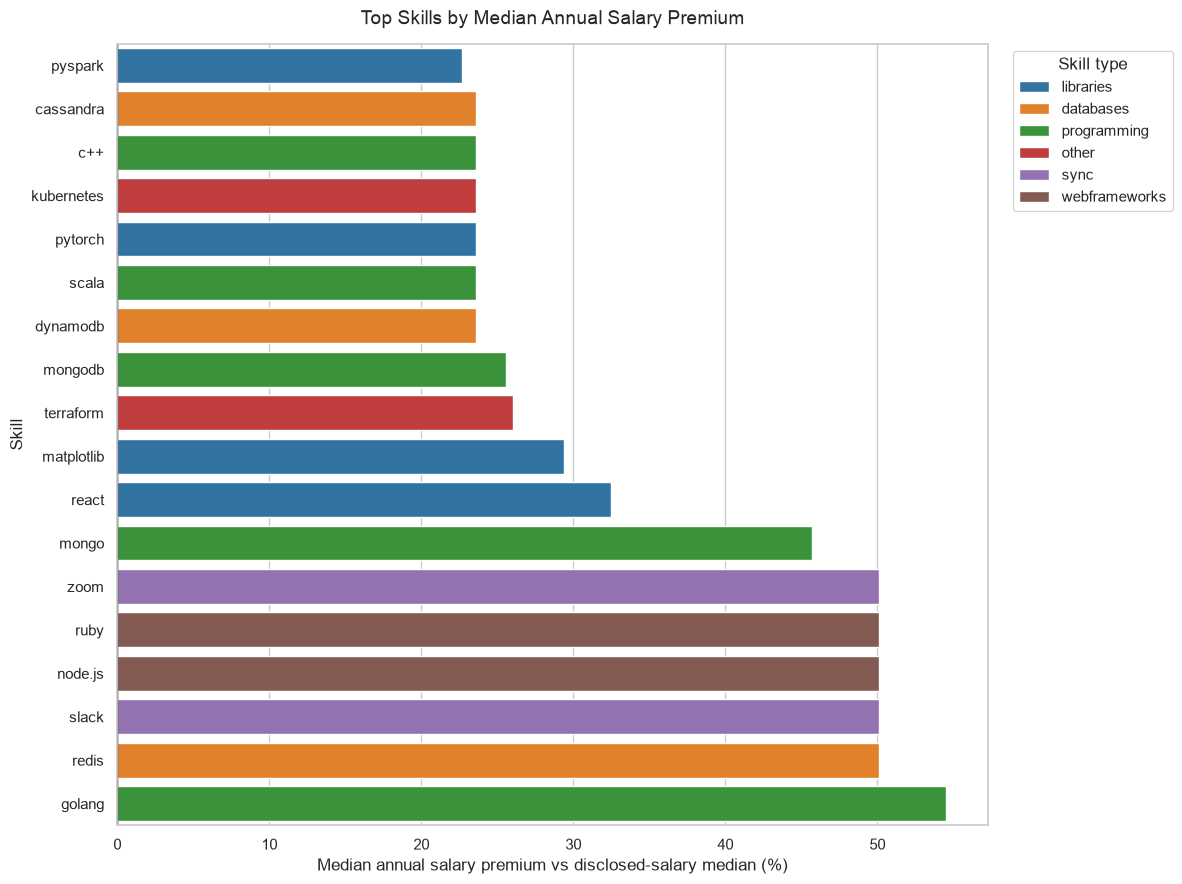

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

TOP_N_PREMIUM_SKILLS = 20

top_skill_salary_premium_plot = (
    skill_salary_premium
    .head(TOP_N_PREMIUM_SKILLS)
    .sort_values(
        by="salary_premium_pct",
        ascending=True,
    )
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=top_skill_salary_premium_plot,
    x="salary_premium_pct",
    y="skill_name",
    hue="skill_type",
    dodge=False,
    palette="tab10",
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1,
)

plt.title(
    "Top Skills by Median Annual Salary Premium",
    fontsize=14,
    pad=14,
)

plt.xlabel(
    "Median annual salary premium vs disclosed-salary median (%)"
)

plt.ylabel("Skill")

plt.legend(
    title="Skill type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Skill demand and salary premium table:


,skill_id,skill_name,skill_type,disclosed_salary_postings,median_annual_salary,salary_premium_abs,salary_premium_pct,total_skill_postings,share_of_skill_mapped_postings_pct
24,36,golang,programming,116,"175,000.00","61,750.00",54.53,2647,0.65
101,248,slack,sync,152,"170,000.00","56,750.00",50.11,1651,0.40
65,142,ruby,webframeworks,125,"170,000.00","56,750.00",50.11,2234,0.54
30,59,redis,databases,153,"170,000.00","56,750.00",50.11,3358,0.82
63,138,node.js,webframeworks,125,"170,000.00","56,750.00",50.11,2189,0.53
...,...,...,...,...,...,...,...,...,...
85,195,word,analyst_tools,855,"90,000.00","-23,250.00",-20.53,15609,3.81
84,194,sheets,analyst_tools,117,"90,000.00","-23,250.00",-20.53,3251,0.79
79,188,powerpoint,analyst_tools,719,"81,335.50","-31,914.50",-28.18,13952,3.40
87,197,outlook,analyst_tools,240,"80,000.00","-33,250.00",-29.36,5175,1.26


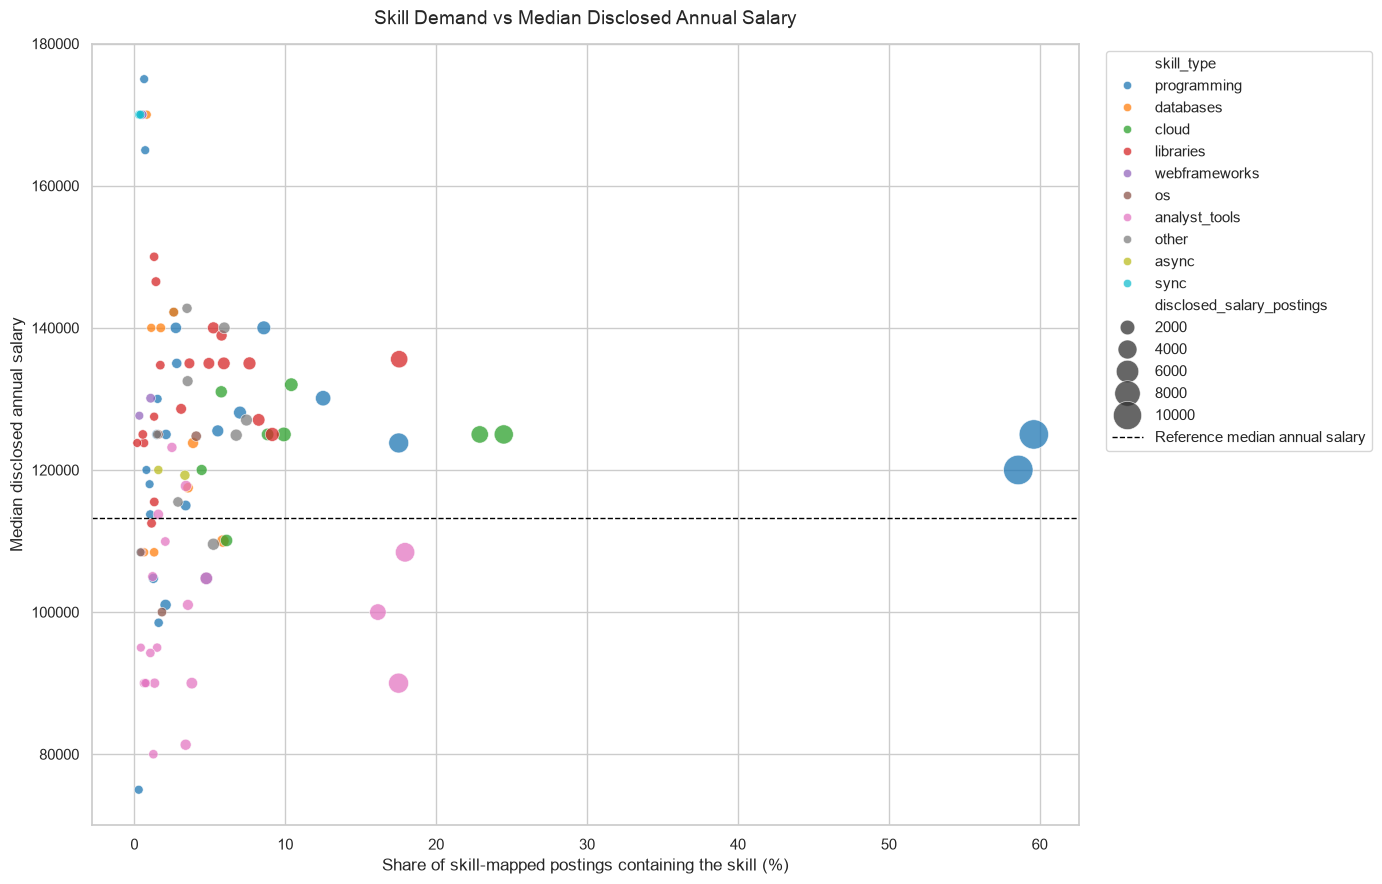

In [8]:
skill_demand_for_salary = (
    salary_postings_with_skills
    .groupby(
        [
            "skill_id",
            "skill_name",
            "skill_type",
        ],
        as_index=False,
    )
    .agg(
        disclosed_salary_postings=("job_id", "nunique"),
        median_annual_salary=("salary_year_avg", "median"),
    )
)

skill_demand_for_salary = (
    skill_demand_for_salary
    .loc[
        skill_demand_for_salary[
            "disclosed_salary_postings"
        ] >= MIN_DISCLOSED_SALARY_POSTINGS
    ]
    .copy()
)

skill_demand_for_salary["salary_premium_abs"] = (
    skill_demand_for_salary["median_annual_salary"]
    - reference_median_annual_salary
)

skill_demand_for_salary["salary_premium_pct"] = (
    skill_demand_for_salary["salary_premium_abs"]
    / reference_median_annual_salary
    * 100
).round(2)

skill_demand_for_salary = skill_demand_for_salary.merge(
    (
        job_skills
        .groupby("skill_id", as_index=False)
        .agg(
            total_skill_postings=("job_id", "nunique"),
        )
    ),
    on="skill_id",
    how="left",
    validate="one_to_one",
)

total_jobs_with_skills = job_skills["job_id"].nunique()

skill_demand_for_salary["share_of_skill_mapped_postings_pct"] = (
    skill_demand_for_salary["total_skill_postings"]
    / total_jobs_with_skills
    * 100
).round(2)

print("Skill demand and salary premium table:")
display(
    skill_demand_for_salary.sort_values(
        by="salary_premium_pct",
        ascending=False,
    )
)

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=skill_demand_for_salary,
    x="share_of_skill_mapped_postings_pct",
    y="median_annual_salary",
    hue="skill_type",
    size="disclosed_salary_postings",
    sizes=(40, 450),
    alpha=0.75,
    palette="tab10",
)

plt.axhline(
    y=reference_median_annual_salary,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Reference median annual salary",
)

plt.title(
    "Skill Demand vs Median Disclosed Annual Salary",
    fontsize=14,
    pad=14,
)

plt.xlabel(
    "Share of skill-mapped postings containing the skill (%)"
)

plt.ylabel("Median disclosed annual salary")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()